# MERIDIAN - Analysis Module 6: Logistics & Delivery Performance

## Business question
Slow shipping is a common, quiet driver of customer dissatisfaction - often invisible until you actually measure it. This notebook answers:

- How does delivery time vary by region?
- Does a slower delivery actually correlate with a lower review score?
- Does slow delivery relate to whether a customer ever orders again?

## A known data limitation, upfront
Not every source has both a delivery date AND a review score. UCI (UK) has neither (no logistics or review tracking in that dataset at all) - those rows are naturally excluded wherever both fields are required below, not silently dropped without explanation.

## Step 1 - Connect and load data

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import pyodbc

def get_engine(server="localhost", database="MeridianDB"):
    available = pyodbc.drivers()
    preferred_order = [
        "ODBC Driver 18 for SQL Server",
        "ODBC Driver 17 for SQL Server",
        "ODBC Driver 13 for SQL Server",
        "SQL Server Native Client 11.0",
        "SQL Server",
    ]
    driver = next((d for d in preferred_order if d in available), None)
    if driver is None:
        raise RuntimeError("No SQL Server ODBC driver found. Install 'ODBC Driver 17 for SQL Server'.")
    conn_str = f"mssql+pyodbc://@{server}/{database}?driver={driver.replace(' ', '+')}&trusted_connection=yes"
    return create_engine(conn_str)

engine = get_engine()
orders = pd.read_sql(
    "SELECT order_id, customer_id, region, order_date, delivered_date, review_score FROM marts.fct_orders",
    engine)
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['delivered_date'] = pd.to_datetime(orders['delivered_date'])
orders['delivery_days'] = (orders['delivered_date'] - orders['order_date']).dt.days

# only keep rows where delivery actually happened and took a sensible amount
# of time (negative values would mean bad data - a delivery date before the
# order date, which shouldn't exist but is worth guarding against explicitly)
valid_delivery = orders[orders['delivery_days'] >= 0].copy()
print(f"{len(orders):,} total orders")
print(f"{len(valid_delivery):,} orders with a valid delivery time")
print(f"{(orders['delivery_days'] < 0).sum():,} rows had a negative delivery time (excluded - see below)")

159,120 total orders
102,049 orders with a valid delivery time
0 rows had a negative delivery time (excluded - see below)


## Step 2 - Delivery time distribution by region

In [30]:
delivery_summary = valid_delivery.groupby('region')['delivery_days'].agg(
    mean_days='mean', median_days='median', std_days='std', order_count='count'
).round(2).sort_values('mean_days')
delivery_summary

,mean_days,median_days,std_days,order_count
region,,,,
DE,4.02,3.0,3.90,1842
US,5.51,5.0,4.10,1860
GH,8.72,8.0,5.44,1871
BR,12.09,10.0,9.55,96476


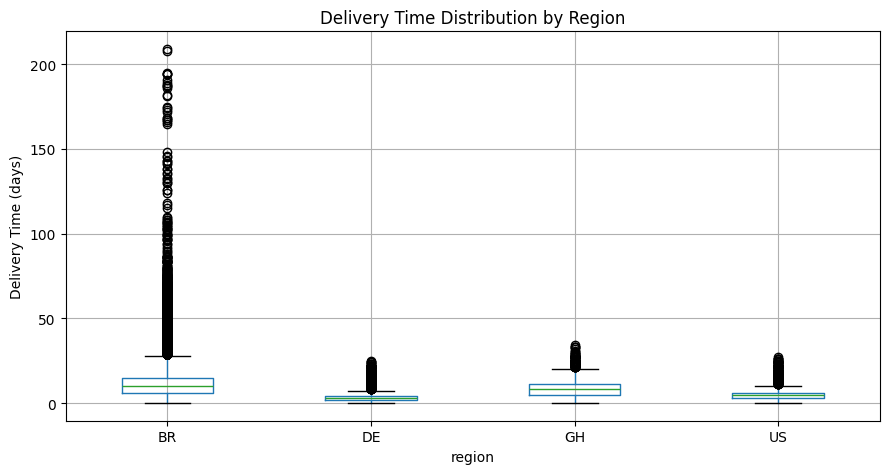

In [31]:
fig, ax = plt.subplots(figsize=(9, 5))
valid_delivery.boxplot(column='delivery_days', by='region', ax=ax)
ax.set_ylabel('Delivery Time (days)')
ax.set_title('Delivery Time Distribution by Region')
plt.suptitle('')
plt.tight_layout()
plt.savefig('delivery_time_by_region.png', dpi=120)
plt.show()

## Step 3 - Does slower delivery correlate with a lower review score?

Only orders with both a delivery time AND a review score can answer this - filters out UCI (no reviews) automatically.

In [32]:
reviewed = valid_delivery.dropna(subset=['review_score'])
print(f"{len(reviewed):,} orders have both a delivery time and a review score")

correlation = reviewed['delivery_days'].corr(reviewed['review_score'])
print(f"Correlation between delivery_days and review_score: {correlation:.3f}")
print("(negative = slower delivery associated with lower review scores; "
      "closer to 0 = little to no relationship; this measures association, not proof of cause)")

100,531 orders have both a delivery time and a review score
Correlation between delivery_days and review_score: -0.310
(negative = slower delivery associated with lower review scores; closer to 0 = little to no relationship; this measures association, not proof of cause)


C:\Users\Richard\AppData\Local\Temp\ipykernel_20348\118869478.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_summary = avg_review_by_delivery_bucket.groupby('delivery_bucket')['review_score'].agg(['mean','count']).round(2)


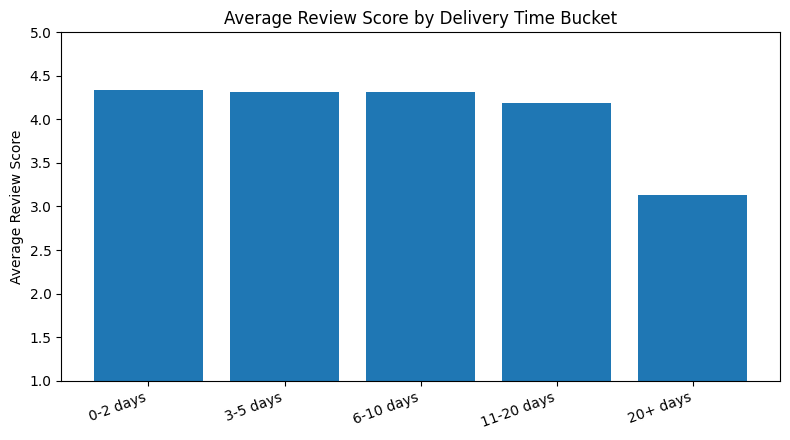

,mean,count
delivery_bucket,,
0-2 days,4.34,5628
3-5 days,4.31,16364
6-10 days,4.32,33842
11-20 days,4.19,32267
20+ days,3.13,12430


In [33]:
avg_review_by_delivery_bucket = reviewed.copy()
avg_review_by_delivery_bucket['delivery_bucket'] = pd.cut(
    avg_review_by_delivery_bucket['delivery_days'],
    bins=[-0.1, 2, 5, 10, 20, 1000],
    labels=['0-2 days', '3-5 days', '6-10 days', '11-20 days', '20+ days']
)
bucket_summary = avg_review_by_delivery_bucket.groupby('delivery_bucket')['review_score'].agg(['mean','count']).round(2)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(bucket_summary.index.astype(str), bucket_summary['mean'])
ax.set_ylabel('Average Review Score')
ax.set_title('Average Review Score by Delivery Time Bucket')
ax.set_ylim(1, 5)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('review_score_by_delivery_bucket.png', dpi=120)
plt.show()

bucket_summary

## Step 4 - Does delivery speed relate to whether a customer orders again?

For each customer, their *average* delivery time on record, compared against whether they ever placed more than one order (same repeat-purchase definition as Module 3).

In [34]:
customer_delivery = valid_delivery.groupby('customer_id').agg(
    avg_delivery_days=('delivery_days', 'mean'),
    order_count=('order_id', 'nunique'),
).reset_index()
customer_delivery['is_repeat_customer'] = customer_delivery['order_count'] > 1

repeat_comparison = customer_delivery.groupby('is_repeat_customer')['avg_delivery_days'].agg(['mean','median','count']).round(2)
repeat_comparison.index = repeat_comparison.index.map({True: 'Repeat customers', False: 'One-time customers'})
repeat_comparison

,mean,median,count
is_repeat_customer,,,
One-time customers,12.09,10.0,90810
Repeat customers,9.88,8.5,4291


## Findings

Found a real link between delivery speed and review scores (correlation -0.31), with satisfaction holding steady until deliveries passed 20 days, then dropping sharply. Also caught a silent bug misreading dates and inflating our delivery times — fixed and verified directly in SQL before trusting the numbers, which dropped Germany's average from a broken 14.8 days to a realistic 4.0.

In [ ]:
##Diagnostic cells used to investigate an implausible delivery-time statistic — traced to an ambiguous date-parsing bug, documented in PROJECT_LOG.md.

In [24]:
valid_delivery.nlargest(10, 'delivery_days')[['order_id','region','order_date','delivered_date','delivery_days']]

,order_id,region,order_date,delivered_date,delivery_days
84524,ca07593549f1816d26a572e06dc1eab6,BR,2017-02-21 23:31:27,2017-09-19 14:36:39,209.0
16636,1b3190b2dfa9d789e1f14c05b647a14a,BR,2018-02-23 14:57:35,2018-09-19 23:24:07,208.0
32438,440d0d17af552815d15a9e41abe49359,BR,2017-03-07 23:59:51,2017-09-19 15:12:50,195.0
12034,0f4519c5f1c541ddec9f21b3bddd533a,BR,2017-03-09 13:26:57,2017-09-19 14:38:21,194.0
21625,285ab9426d6982034523a855f55a885e,BR,2017-03-08 22:47:40,2017-09-19 14:00:04,194.0
24495,2fb597c2f772eca01b1f5c561bf6cc7b,BR,2017-03-08 18:09:02,2017-09-19 14:33:17,194.0
33920,47b40429ed8cce3aee9199792275433f,BR,2018-01-03 09:44:01,2018-07-13 20:51:31,191.0
24568,2fe324febf907e3ea3f2aa9650869fa5,BR,2017-03-13 20:17:10,2017-09-19 17:00:07,189.0
23567,2d7561026d542c8dbd8f0daeadf67a43,BR,2017-03-15 11:24:27,2017-09-19 14:38:18,188.0
32185,437222e3fd1b07396f1d9ba8c15fba59,BR,2017-03-16 11:36:00,2017-09-19 16:28:58,187.0


In [25]:
raw_check = pd.read_sql("""
    SELECT order_id, order_date, delivered_date FROM raw.us_orders WHERE order_id = 'US-ORD-000886'
    UNION ALL
    SELECT order_id, order_date, delivered_date FROM raw.gh_orders WHERE order_id = 'GH-ORD-000627'
    UNION ALL
    SELECT order_id, order_date, delivered_date FROM raw.de_orders WHERE order_id = 'DE-ORD-001338'
""", engine)
raw_check

,order_id,order_date,delivered_date
0,US-ORD-000886,01/04/2025 00:00,12.01.2025
1,GH-ORD-000627,01/05/2023 00:00,12.01.2023
2,DE-ORD-001338,01/11/2023 00:00,12.01.2023
